In [ ]:
## Connecting to Drive for the Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

## Defining the path to the dataset in the drive
zip_path = '/content/drive/MyDrive/Data_Science/COVID-19 Dataset.zip'

## path where we want to extract the dataset into
extract_path = '/content/dataset'

## Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
## path where the zip file was extracted
base_path = '/content/dataset'

## before moving on doing checks on the folder names so that which to use can be identified
for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')

dataset/
    COVID-19_Radiography_Dataset/
        Viral Pneumonia/
            masks/
            images/
        COVID/
            masks/
            images/
        Normal/
            masks/
            images/
        Lung_Opacity/
            masks/
            images/


In [ ]:
## importing the needed Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Defining the Base Directory
base_dir = '/content/dataset/COVID-19_Radiography_Dataset'

## Defining specific paths for the IMAGES only not using the mask folders not needed
covid_images_path = os.path.join(base_dir, 'COVID/images')
normal_images_path = os.path.join(base_dir, 'Normal/images')
pneumonia_images_path = os.path.join(base_dir, 'Viral Pneumonia/images')
opacity_images_path = os.path.join(base_dir, 'Lung_Opacity/images')

## Verifying by printing the number of images in each category
print(f"COVID Images: {len(os.listdir(covid_images_path))}")
print(f"Normal Images: {len(os.listdir(normal_images_path))}")
print(f"Viral Pneumonia Images: {len(os.listdir(pneumonia_images_path))}")
print(f"Lung Opacity Images: {len(os.listdir(opacity_images_path))}")

COVID Images: 3616
Normal Images: 10192
Viral Pneumonia Images: 1345
Lung Opacity Images: 6012


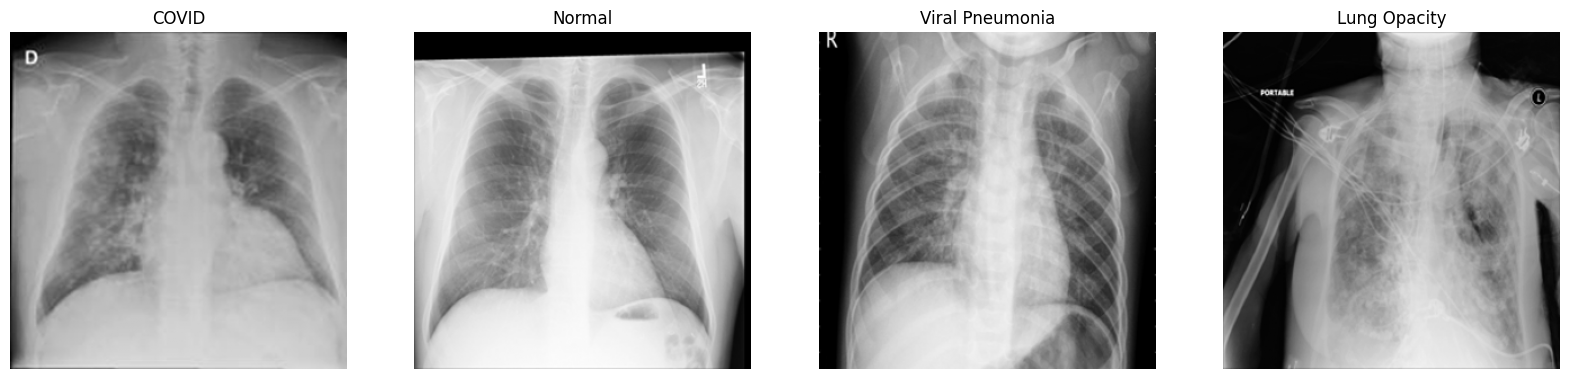

In [ ]:
## importing needed library to see the visual(images) whether we have correct images and have access to the folder
import matplotlib.image as mpimg
import random

## Creating a figure to display the images
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
categories = ['COVID', 'Normal', 'Viral Pneumonia', 'Lung Opacity']
paths = [covid_images_path, normal_images_path, pneumonia_images_path, opacity_images_path]

for i in range(4):
    ## Getting a random image from the category
    random_image_name = random.choice(os.listdir(paths[i]))
    image_path = os.path.join(paths[i], random_image_name)

    ## Reading and display the image
    img = mpimg.imread(image_path)
    ax[i].imshow(img, cmap='gray')
    ax[i].set_title(categories[i])
    ax[i].axis('off')

plt.show()

## **Step 3: Data Preprocessing**

In [ ]:
## Create a DataFrame to store file paths and labels
data = []

## Defining a dictionary to map the paths to their labels
categories_map = {
    covid_images_path: 'COVID',
    normal_images_path: 'Normal',
    pneumonia_images_path: 'Viral Pneumonia',
    opacity_images_path: 'Lung Opacity'
}

## Loop through each category and add file paths to the list
for path, label in categories_map.items():
    for file in os.listdir(path):
        if file.lower().endswith(('.png', '.jpg', '.jpeg')): ## adding multiple image format just to be sure enough we include all the images
             data.append({'Filepath': os.path.join(path, file), 'Label': label})

## Converting to Pandas DataFrame
df = pd.DataFrame(data)

## Shuffling the dataset (randomize the order)
df = df.sample(frac=1).reset_index(drop=True)

## Displaying the first few rows and the total counts
print(df.head())
print("\nTotal counts per category:")
print(df['Label'].value_counts())

                                            Filepath            Label
0  /content/dataset/COVID-19_Radiography_Dataset/...            COVID
1  /content/dataset/COVID-19_Radiography_Dataset/...  Viral Pneumonia
2  /content/dataset/COVID-19_Radiography_Dataset/...           Normal
3  /content/dataset/COVID-19_Radiography_Dataset/...           Normal
4  /content/dataset/COVID-19_Radiography_Dataset/...     Lung Opacity

Total counts per category:
Label
Normal             10192
Lung Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


In [ ]:
## Importing the necessary library for the splitting of data for training and testing purpose
from sklearn.model_selection import train_test_split

## Spliting Data into Train (80%) and Temp (20%)
train_df, temp_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42, stratify=df['Label'])

## Spliting Temp (20%) into Validation (10%) and Test (10%)
val_df, test_df = train_test_split(temp_df, train_size=0.5, shuffle=True, random_state=42, stratify=temp_df['Label'])

## Printing the results
print(f"Training Set Shape: {train_df.shape}")
print(f"Validation Set Shape: {val_df.shape}")
print(f"Test Set Shape: {test_df.shape}")

## Verify stratification (ratios should be roughly equal)
print("\nTraining Label Distribution:")
print(train_df['Label'].value_counts(normalize=True))

Training Set Shape: (16932, 2)
Validation Set Shape: (2116, 2)
Test Set Shape: (2117, 2)

Training Label Distribution:
Label
Normal             0.481573
Lung Opacity       0.284018
COVID              0.170860
Viral Pneumonia    0.063548
Name: proportion, dtype: float64


In [ ]:
## Defining the parameters for rescaling the images to 224 X 224 pixel for better and standard size for training
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

## 1. Training Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize pixel values to 0-1
    rotation_range=20,      # Rotate slightly
    width_shift_range=0.1,  # Shift horizontally
    height_shift_range=0.1, # Shift vertically
    shear_range=0.1,        # Shear transformation
    zoom_range=0.1,         # Zoom in/out slightly
    horizontal_flip=True,   # Flip horizontally
    fill_mode='nearest'
)

## 2. Validation & Test Generator
test_datagen = ImageDataGenerator(rescale=1./255)

## 3. Create the Flow from DataFrames
print("Setting up Training Generator:")
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\nSetting up Validation Generator:")
val_gen = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nSetting up Test Generator:")
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Setting up Training Generator:
Found 16932 validated image filenames belonging to 4 classes.

Setting up Validation Generator:
Found 2116 validated image filenames belonging to 4 classes.

Setting up Test Generator:
Found 2117 validated image filenames belonging to 4 classes.


In [ ]:
## Importing the needed libraries for building model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

## 1. Load the Pre-trained Base Model
## weights='imagenet' loads the pre-learned patterns
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

## 2. Freeze the Base Model for our custom changes we add
base_model.trainable = False

## 3. Building the Model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),       ## Condense information
    Dense(256, activation='relu'),  ## Hidden layer to learn new patterns
    Dropout(0.5),                   ## Drop 50% of neurons randomly to prevent overfitting
    Dense(4, activation='softmax')  ## Output layer: 4 neurons for our 4 categories
])

## 4. Compiling the Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Checking the summary to see if the model was built properly
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,932 (27.85 MB)

 Trainable params: 263,428 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
## Importing the necessary libraries for the model training
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

## using callbacks and early stoppping to prevent over fitting and prevents model from training if the model doesnt improving saving time and resources

## Define Callbacks
checkpoint = ModelCheckpoint(
    'best_covid_model.keras',      ## File to save
    monitor='val_accuracy',        ## Watch validation accuracy
    save_best_only=True,           ## Only save if it's better than before
    mode='max',                    ## We want accuracy to be maximum
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',            ## Watch validation loss
    patience=5,                    ## Stop if no improvement for 5 epochs
    restore_best_weights=True,     ## Go back to the best weights found
    verbose=1
)

## Training the Model
history = model.fit(
    train_gen,
    epochs=15, ## the number of times our model goes through the dataset to learn the more number better accuracy but also over fitting fear
    validation_data=val_gen,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.7019 - loss: 0.7636
Epoch 1: val_accuracy improved from -inf to 0.79868, saving model to best_covid_model.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 275s 518ms/step - accuracy: 0.7019 - loss: 0.7634 - val_accuracy: 0.7987 - val_loss: 0.5355
Epoch 2/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7964 - loss: 0.5452
Epoch 2: val_accuracy did not improve from 0.79868
530/530 ━━━━━━━━━━━━━━━━━━━━ 242s 457ms/step - accuracy: 0.7964 - loss: 0.5452 - val_accuracy: 0.7765 - val_loss: 0.5812
Epoch 3/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.8147 - loss: 0.4955
Epoch 3: val_accuracy improved from 0.79868 to 0.81616, saving model to best_covid_model.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 240s 453ms/step - accuracy: 0.8146 - loss: 0.4955 - val_accuracy: 0.8162 - val_loss: 0.4827
Epoch 4/15
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8186 - loss: 0.4880
Epoch 4: val_accuracy did not improve from 0.81

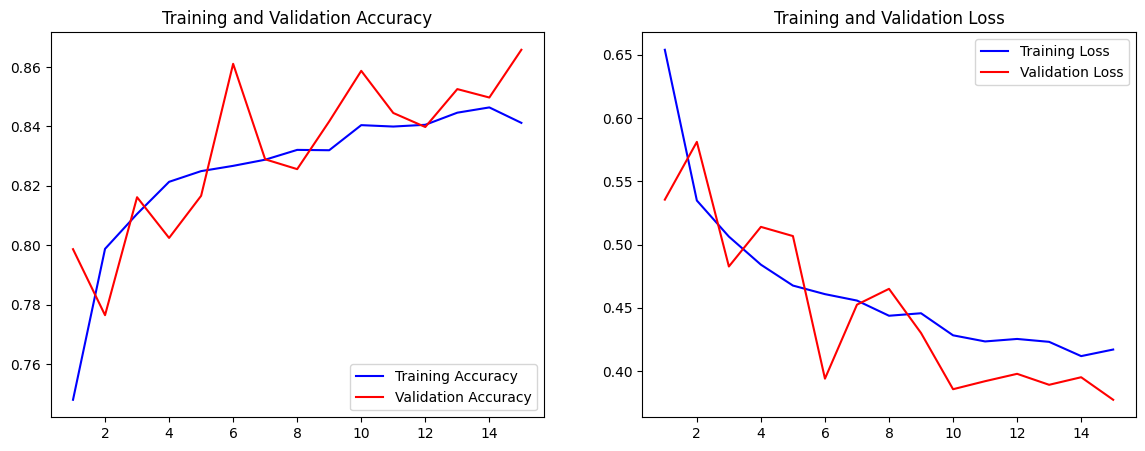

In [ ]:
## importing the libary to plot the graphs on how the model trained on our dataset
import matplotlib.pyplot as plt

## Get the accuracy and loss values from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

## Creating a figure with two subplots side-by-side
plt.figure(figsize=(14, 5))

## Plotting Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

## Plotting Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [ ]:
## 1. Load the best weights saved during training
model.load_weights('best_covid_model.keras')

## 2. Evaluate on the Test Set
print("Evaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_gen)


## printing the accuracy and loss when tested on the test set
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Evaluating on Test Set...
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 324ms/step - accuracy: 0.8585 - loss: 0.3693

Test Accuracy: 86.11%
Test Loss: 0.3692


67/67 ━━━━━━━━━━━━━━━━━━━━ 35s 296ms/step


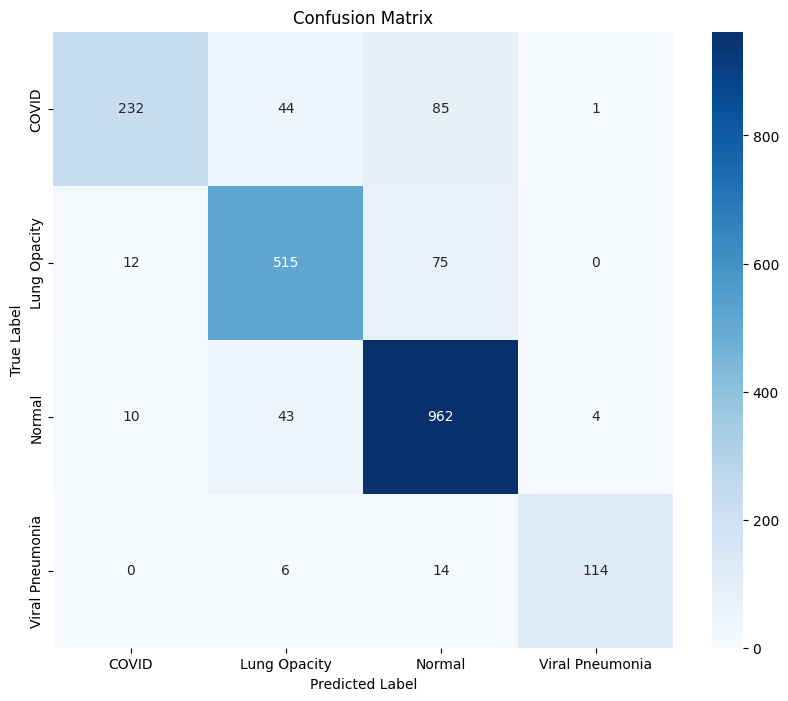


Classification Report:

                 precision    recall  f1-score   support

          COVID       0.91      0.64      0.75       362
   Lung Opacity       0.85      0.86      0.85       602
         Normal       0.85      0.94      0.89      1019
Viral Pneumonia       0.96      0.85      0.90       134

       accuracy                           0.86      2117
      macro avg       0.89      0.82      0.85      2117
   weighted avg       0.87      0.86      0.86      2117



In [ ]:
## importing the libraries for plotting and getting the classification report and  matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

## Getting Predictions
test_gen.reset()
predictions = model.predict(test_gen, verbose=1)

## Converting probabilities to class labels (0, 1, 2, 3)
y_pred = np.argmax(predictions, axis=1)

## Getting true labels from the generator
y_true = test_gen.classes

## Getting class names
class_names = list(test_gen.class_indices.keys())

## Generating Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

## Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Printing Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# **Project Summary & Conclusion**

## **1. Methodology**
To detect COVID-19 from Chest X-Ray images, we implemented a Deep Learning approach using **Transfer Learning**.

* **Dataset:**
    * Source: COVID-19 Radiography Database.
    * Classes: COVID-19, Normal, Viral Pneumonia, Lung Opacity.
    * Total Images: ~21,000 (Split: 80% Train, 10% Val, 10% Test).

* **Preprocessing:**
    * **Resizing:** All images resized to **224x224 pixels**.
    * **Normalization:** Pixel values scaled to range [0, 1].
    * **Augmentation:** Applied to training data (Rotation, Zoom, Horizontal Flip) to improve generalization and handle class imbalance.

* **Model Architecture:**
    * **Base Model:** **DenseNet121** (Pre-trained on ImageNet) was selected for its efficiency in feature extraction from medical images.
    * **Custom Head:** Added Global Average Pooling, a Dense layer (256 neurons, ReLU), Dropout (0.5) to prevent overfitting, and a final Softmax output layer.
    * **Freezing:** The base DenseNet layers were frozen to preserve pre-learned features.

* **Training Configuration:**
    * **Optimizer:** Adam (Learning Rate = 0.001).
    * **Loss Function:** Categorical Crossentropy.
    * **Callbacks:** Implemented **EarlyStopping** (Patience=5) and **ModelCheckpoint** to save the best model weights.

---

## **2. Results & Performance**
The model was evaluated on an unseen Test Set of ~2,100 images.

* **Overall Accuracy:** **86.11%**
* **COVID-19 Performance:**
    * **Precision:** **91%** (High reliability; few false positives).
    * **Recall:** **64%** (Moderate sensitivity; some missed cases).
* **Generalization:** The model showed consistent performance between Validation and Test sets, indicating no significant overfitting.

---

## **3. Conclusion**
This Capstone Project successfully demonstrated the application of **Transfer Learning** for medical image classification. By leveraging the **DenseNet121** architecture, we achieved a robust accuracy of over **86%**.

* **Key Insight:** The model is highly precise in identifying COVID-19 (91% Precision), making it a reliable tool for confirming positive cases.
* **Challenge:** The lower recall (64%) for COVID-19 suggests the model struggles slightly to distinguish some COVID cases from other lung opacities, likely due to the dataset imbalance (fewer COVID images compared to Normal cases).

## **4. Future Scope**
To further improve performance in a real-world setting:
* **Fine-Tuning:** Unfreezing the top layers of DenseNet121 to adapt specific features to X-rays.
* **Class Balancing:** Using techniques like SMOTE or calculating "Class Weights" during training to penalize the model more for missing COVID cases.
* **Ensemble Methods:** Combining predictions from DenseNet121 with ResNet50 for higher stability.